# EDA 01 — Estructura y calidad de datos

**Dataset:** `data/processed/propiedades_argenprop_curado.csv` (salida del pipeline de curation).

**Objetivos de este notebook:**
1. Confirmar la estructura del dataset (filas, columnas, dtypes).
2. Cuantificar datos faltantes por columna.
3. Identificar columnas con cobertura nula o casi nula (candidatas a descartar).
4. Verificar unicidad de los identificadores y cardinalidad de las variables categóricas.

## Configuración

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RUTA_DATASET = Path("../data/processed/propiedades_argenprop_curado.csv")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)

In [2]:
df = pd.read_csv(RUTA_DATASET, low_memory=False)
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Filas: 2,005 | Columnas: 32


## 1. Estructura

In [3]:
df.dtypes

id                                     int64
link                                     str
titulo                                   str
descripcion                              str
tipo_propiedad                           str
idtipopropiedad                        int64
barrio                                   str
sub_barrio                               str
precio                               float64
moneda                                   str
expensas                             float64
superficie_cubierta                  float64
superficie_semicubierta              float64
superficie_total                     float64
ambientes                            float64
dormitorios                          float64
banos                                float64
cocheras                             float64
antiguedad                           float64
fecha_scrape                             str
tipo_cambio_ars_usd                  float64
precio_usd                           float64
expensas_u

### 1.1 Columnas por rol

Las 32 columnas se agrupan en: identificador y link, texto del aviso, características de la propiedad, precio, moneda, expensas, fechas, y los indicadores `*_informado` generados por la curación.

In [4]:
informado = [c for c in df.columns if c.endswith("_informado")]
numericas = [
    c
    for c in df.select_dtypes("number").columns
    if c not in informado and c not in ("id", "idtipopropiedad")
]

print("Identificadores:", ["id", "idtipopropiedad"])
print(
    "Texto:",
    [
        "link",
        "titulo",
        "descripcion",
        "barrio",
        "sub_barrio",
        "tipo_propiedad",
        "moneda",
        "fecha_scrape",
    ],
)
print("Numéricas (atributos):", numericas)
print("Indicadores de missing:", informado)

Identificadores: ['id', 'idtipopropiedad']
Texto: ['link', 'titulo', 'descripcion', 'barrio', 'sub_barrio', 'tipo_propiedad', 'moneda', 'fecha_scrape']
Numéricas (atributos): ['precio', 'expensas', 'superficie_cubierta', 'superficie_semicubierta', 'superficie_total', 'ambientes', 'dormitorios', 'banos', 'cocheras', 'antiguedad', 'tipo_cambio_ars_usd', 'precio_usd', 'expensas_usd']
Indicadores de missing: ['expensas_informado', 'superficie_cubierta_informado', 'superficie_semicubierta_informado', 'superficie_total_informado', 'ambientes_informado', 'dormitorios_informado', 'banos_informado', 'cocheras_informado', 'antiguedad_informado']


## 2. Calidad de datos

### 2.1 Datos faltantes

La curación ya registra explícitamente qué atributos no fueron informados por el aviso mediante los indicadores `*_informado`. Este análisis complementa esa visión con los porcentajes crudos.

In [5]:
missing = df.isna().mean().mul(100).sort_values(ascending=False).rename("missing_%").to_frame()
missing.head(15)

,missing_%
cocheras,100.000000
superficie_semicubierta,98.553616
superficie_total,97.007481
sub_barrio,88.827930
banos,69.127182
antiguedad,41.845387
expensas_usd,33.665835
expensas,33.665835
dormitorios,15.361596
superficie_cubierta,7.581047


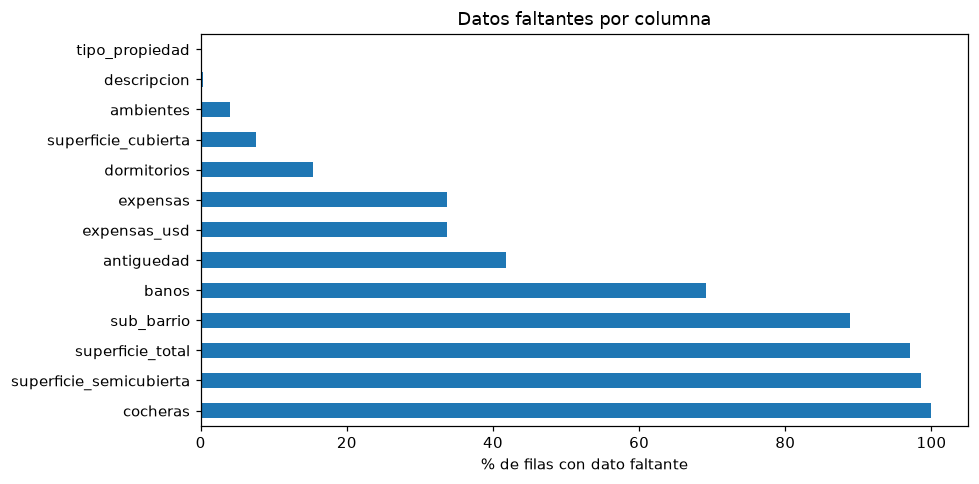

In [6]:
fig, ax = plt.subplots()
missing.loc[missing["missing_%"] > 0, "missing_%"].plot.barh(ax=ax)
ax.set_xlabel("% de filas con dato faltante")
ax.set_title("Datos faltantes por columna")
plt.tight_layout()
plt.show()

### 2.2 Columnas con cobertura casi nula

Tres columnas tienen más del 97% de valores faltantes:

- `cocheras`: 100% faltante (el scraper no la captura de la tarjeta).
- `superficie_semicubierta`: 98.6% faltante.
- `superficie_total`: 97.0% faltante.

Son candidatas a descartarse en feature engineering: con esta cobertura no aportan señal y sus indicadores `*_informado` están casi constantes.

In [7]:
casi_vacias = missing[missing["missing_%"] >= 97].index.tolist()
print("Candidatas a descartar:", casi_vacias)
print("\n¿Los indicadores *_informado de esas columnas están casi constantes?")
for c in casi_vacias:
    col = c + "_informado"
    if col in df:
        print(f"  {col}:", df[col].value_counts().to_dict())

Candidatas a descartar: ['cocheras', 'superficie_semicubierta', 'superficie_total']

¿Los indicadores *_informado de esas columnas están casi constantes?
  cocheras_informado: {0: 2005}
  superficie_semicubierta_informado: {0: 1976, 1: 29}
  superficie_total_informado: {0: 1945, 1: 60}


### 2.3 Identificadores y duplicados

In [8]:
print("id únicos:", df["id"].nunique(), "de", len(df), "filas")
print("id duplicados:", df["id"].duplicated().sum())
print(
    "filas totalmente duplicadas:",
    df.drop(columns=["fecha_scrape"]).duplicated().sum(),
)

id únicos: 2005 de 2005 filas
id duplicados: 0
filas totalmente duplicadas: 0


### 2.4 Variables categóricas

In [ ]:
print("tipo_propiedad:\n", df["tipo_propiedad"].value_counts(dropna=False).to_string())
print(f"\nbarrio: {df['barrio'].nunique()} únicos")
print("\nmoneda:\n", df["moneda"].value_counts(dropna=False).to_string())

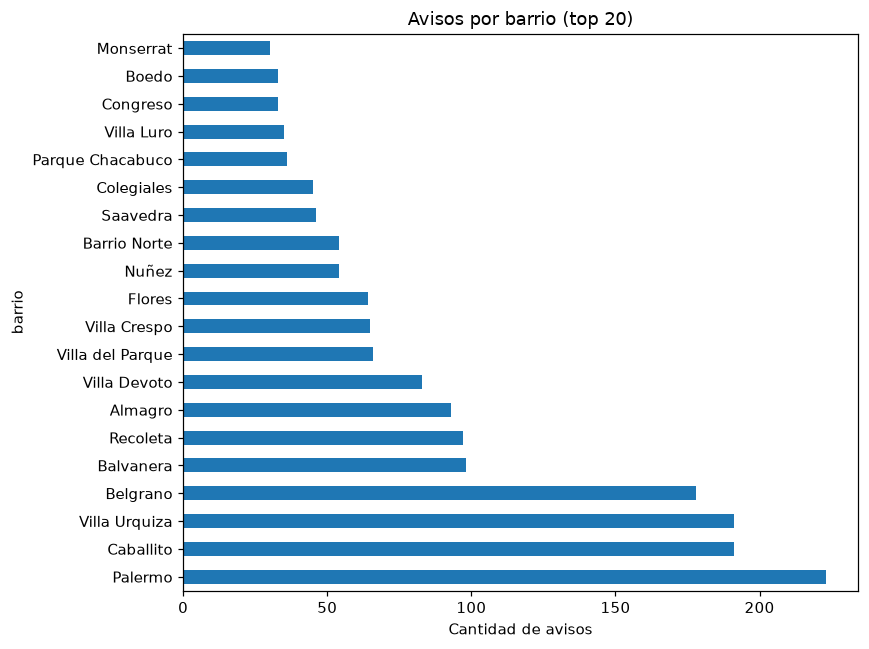

In [10]:
df["barrio"].value_counts().head(20).plot.barh(figsize=(8, 6))
plt.xlabel("Cantidad de avisos")
plt.title("Avisos por barrio (top 20)")
plt.tight_layout()
plt.show()

## 3. Hallazgos clave

1. **Estructura sólida:** 2.005 avisos, 32 columnas, sin duplicados de `id`.
2. **Target sin faltantes:** `precio_usd` está completo (todas las filas quedaron en USD tras la normalización de moneda).
3. **Cobertura irregular:** `ambientes` (96%) y `superficie_cubierta` (92%) son los atributos mejor cubiertos; `dormitorios` 85%; `banos` 31%; `antiguedad` 58%; `expensas` 66%.
4. **Candidatas a descartar:** `cocheras` (100% faltante), `superficie_semicubierta` (98.6%) y `superficie_total` (97%).
5. **Categorías:** 8 tipos de propiedad (86% departamentos), 44 barrios con 4 barrios dominantes (Palermo, Caballito, Villa Urquiza, Belgrano ≈ 39% del total).